In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
import scanpy as sc
import torch
import scarches as sca
from scarches.dataset.trvae.data_handling import remove_sparsity
import matplotlib.pyplot as plt
import numpy as np
import gdown

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 captum (see https://github.com/pytorch/captum).


In [3]:
import pandas as pd

In [4]:
sc.settings.set_figure_params(dpi=200, frameon=False)
sc.set_figure_params(dpi=200)
sc.set_figure_params(figsize=(4, 4))
torch.set_printoptions(precision=3, sci_mode=False, edgeitems=7)

## load query

In [18]:
haniffaAd = sc.read_h5ad('haniffalab_QC.h5ad')

In [19]:
haniffaAd.obs.columns

Index(['disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location',
       'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue',
       'dataset_id', 'doublet_scores', 'predicted_doublets',
       'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes'],
      dtype='object')

In [20]:
haniffaAd.obs["cell_type"].value_counts()

Th                    55168
nan                   34175
Tc                    15952
Treg                  13071
Inf_mono               7970
moDC_1                 7464
Macro_1                7179
Mono                   7131
LC_3                   6231
LC_4                   5897
moDC_2                 5534
Pericyte_2_inflamm     5253
DC2                    5113
LE2                    5091
LC_2                   4747
MigDC                  4408
ILC1_3                 3932
moDC_3                 3815
ILC1_NK                3323
Macro_2                2710
DC1                    1936
LC_1                   1812
Mast_cell               897
NK                      886
ILC2                    666
Plasma                   82
Name: cell_type, dtype: int64

In [21]:
removed_cells = ['Differentiated_KC', 'Proliferating_KC', 'VE2', 'F2', 'Undifferentiated_KC*', 'Pericyte_2_inflamm',
                                                           'Differentiated_KC*', 'F1', 'VE1', 'F3', 'Pericyte_1_non_inflamm', 'Melanocyte',
                                                           'VE3', 'LE1', 'Schwann1', 'Schwann2']

In [22]:
removed_cells

['Differentiated_KC',
 'Proliferating_KC',
 'VE2',
 'F2',
 'Undifferentiated_KC*',
 'Pericyte_2_inflamm',
 'Differentiated_KC*',
 'F1',
 'VE1',
 'F3',
 'Pericyte_1_non_inflamm',
 'Melanocyte',
 'VE3',
 'LE1',
 'Schwann1',
 'Schwann2']

In [23]:
haniffaAd

AnnData object with n_obs × n_vars = 210443 × 33538
    obs: 'disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue', 'dataset_id', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes'
    var: 'gene_ids-SKN8090524', 'feature_types-SKN8090524', 'mt', 'rb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p'
    layers: 'counts'

In [24]:
haniffaAd = haniffaAd[~haniffaAd.obs.cell_type.isin(removed_cells)]

In [25]:
#haniffaAd.var = haniffaAd.var[['gene_ids-SKN8090524', 'feature_types-SKN8090524']]

In [27]:
#haniffaAd.obs["tissue"] = haniffaAd.obs.Tissue
haniffaAd.obs["dataset_id"] = "Skin_Reynolds_et_al"

In [28]:
haniffaAd.obs.columns

Index(['disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location',
       'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue',
       'dataset_id', 'doublet_scores', 'predicted_doublets',
       'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes'],
      dtype='object')

In [30]:
#haniffaAd.obs.columns = ['disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 
   #                      'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue', 'dataset_id']

In [31]:
adata_Braga = sc.read_h5ad("Braga_asthma_lung_celltypist.h5ad")

In [32]:
adata_Braga = adata_Braga[adata_Braga.obs.main_predicted_cell_groups.isin(['Classical monocytes', 'Mast cells', 'CD4 T cells', 
                                                           'DC2', 'CD8 T cells', 'Non-classical monocytes', 'NK cells', 
                                                           'B cells', 'Alveolar macrophages', 'Plasmacytoid DCs', 'Plasma cells'])].copy()

In [33]:
adata_query = adata_Braga.concatenate(haniffaAd, batch_key="ref_query")

In [34]:
del haniffaAd
del adata_Braga
adata_query

AnnData object with n_obs × n_vars = 223443 × 31915
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'main_predicted_cell_groups', 'leiden', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 'development_stage', 'cell_type', 'ref_query'
    var: 'gene_ids-SKN8090524-1', 'feature_types-SKN8090524-1', 'mt-1', 'rb-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1'
    layers: 'counts'

In [35]:
adata_query.obs.dataset_id.value_counts()

Skin_Reynolds_et_al    205190
Braga_asthma            18253
Name: dataset_id, dtype: int64

## load reference

In [36]:
adata_ref = sc.read_h5ad("Myeloid_B_T_From_Tissue_label_transfert_Subset_annotated_Milo_3K.h5ad")

In [37]:
commonGen = [gen for gen in adata_query.var_names if gen in adata_ref.var_names]

In [38]:
commonGen[:10]

['FAM87B',
 'LINC00115',
 'SAMD11',
 'NOC2L',
 'KLHL17',
 'PLEKHN1',
 'HES4',
 'ISG15',
 'AGRN',
 'RNF223']

In [39]:
adata_ref = adata_ref[:, commonGen]

In [40]:
adata_ref

View of AnnData object with n_obs × n_vars = 365203 × 17209
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0', 'total_counts-0-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0', 'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'n_cells_by_counts-1-0-0', 'mean_counts-1-0-0', 'pct_dropout_by_counts-1-0-0', 'total_counts-1-0-0', 'gene_symbol-1-0-0-0-0-0-0-1-1-0', 'n_c

In [41]:
sc.pp.highly_variable_genes(
    adata_ref,
    n_top_genes=5000,
    batch_key="dataset_id",
    subset=True)

In [42]:
adata_ref.X = adata_ref.raw[:, adata_ref.var_names].X

In [43]:
adata_query = adata_query[:, adata_ref.var_names]

In [44]:
adata_ref

AnnData object with n_obs × n_vars = 365203 × 5000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0', 'total_counts-0-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0', 'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'n_cells_by_counts-1-0-0', 'mean_counts-1-0-0', 'pct_dropout_by_counts-1-0-0', 'total_counts-1-0-0', 'gene_symbol-1-0-0-0-0-0-0-1-1-0', 'n_cells_by_c

## SCVI model

In [45]:
sca.models.SCVI.setup_anndata(adata_ref,  batch_key="donor_id", labels_key="Cell_type_scANVI")

In [46]:
vae = sca.models.SCVI(
    adata_ref,
    n_layers=3,
    encode_covariates=True,
    deeply_inject_covariates=False,
    use_layer_norm="both",
    use_batch_norm="none",
)

In [47]:
early_stopping_kwargs = {
    #"early_stopping_metric": "elbo",
    "save_best_state_metric": "elbo",
    "patience": 10,
    "threshold": 0,
    "reduce_lr_on_plateau": True,
    "lr_patience": 8,
    "lr_factor": 0.1,
}
vae.train()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 22/22: 100%|██████████| 22/22 [13:16<00:00, 36.12s/it, v_num=1, train_loss_step=981, train_loss_epoch=1.01e+3]    

INFO: `Trainer.fit` stopped: `max_epochs=22` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=22` reached.


Epoch 22/22: 100%|██████████| 22/22 [13:16<00:00, 36.21s/it, v_num=1, train_loss_step=981, train_loss_epoch=1.01e+3]


In [48]:
scanvae = sca.models.SCANVI.from_scvi_model(vae, unlabeled_category = "Unknown")

In [49]:
print("Labelled Indices: ", len(scanvae._labeled_indices))
print("Unlabelled Indices: ", len(scanvae._unlabeled_indices))

Labelled Indices:  365203
Unlabelled Indices:  0


In [50]:
scanvae.train()

INFO     Training for 7 epochs.                                                                                    


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 7/7: 100%|██████████| 7/7 [10:35<00:00, 89.93s/it, v_num=1, train_loss_step=1.02e+3, train_loss_epoch=1.03e+3]

INFO: `Trainer.fit` stopped: `max_epochs=7` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=7` reached.


Epoch 7/7: 100%|██████████| 7/7 [10:35<00:00, 90.77s/it, v_num=1, train_loss_step=1.02e+3, train_loss_epoch=1.03e+3]


In [51]:
reference_latent = sc.AnnData(scanvae.get_latent_representation())
reference_latent.obs["Cell_type_scANVI"] = adata_ref.obs["Cell_type_scANVI"].tolist()
reference_latent.obs["dataset_id"] = adata_ref.obs["Cell_type_scANVI"].tolist()


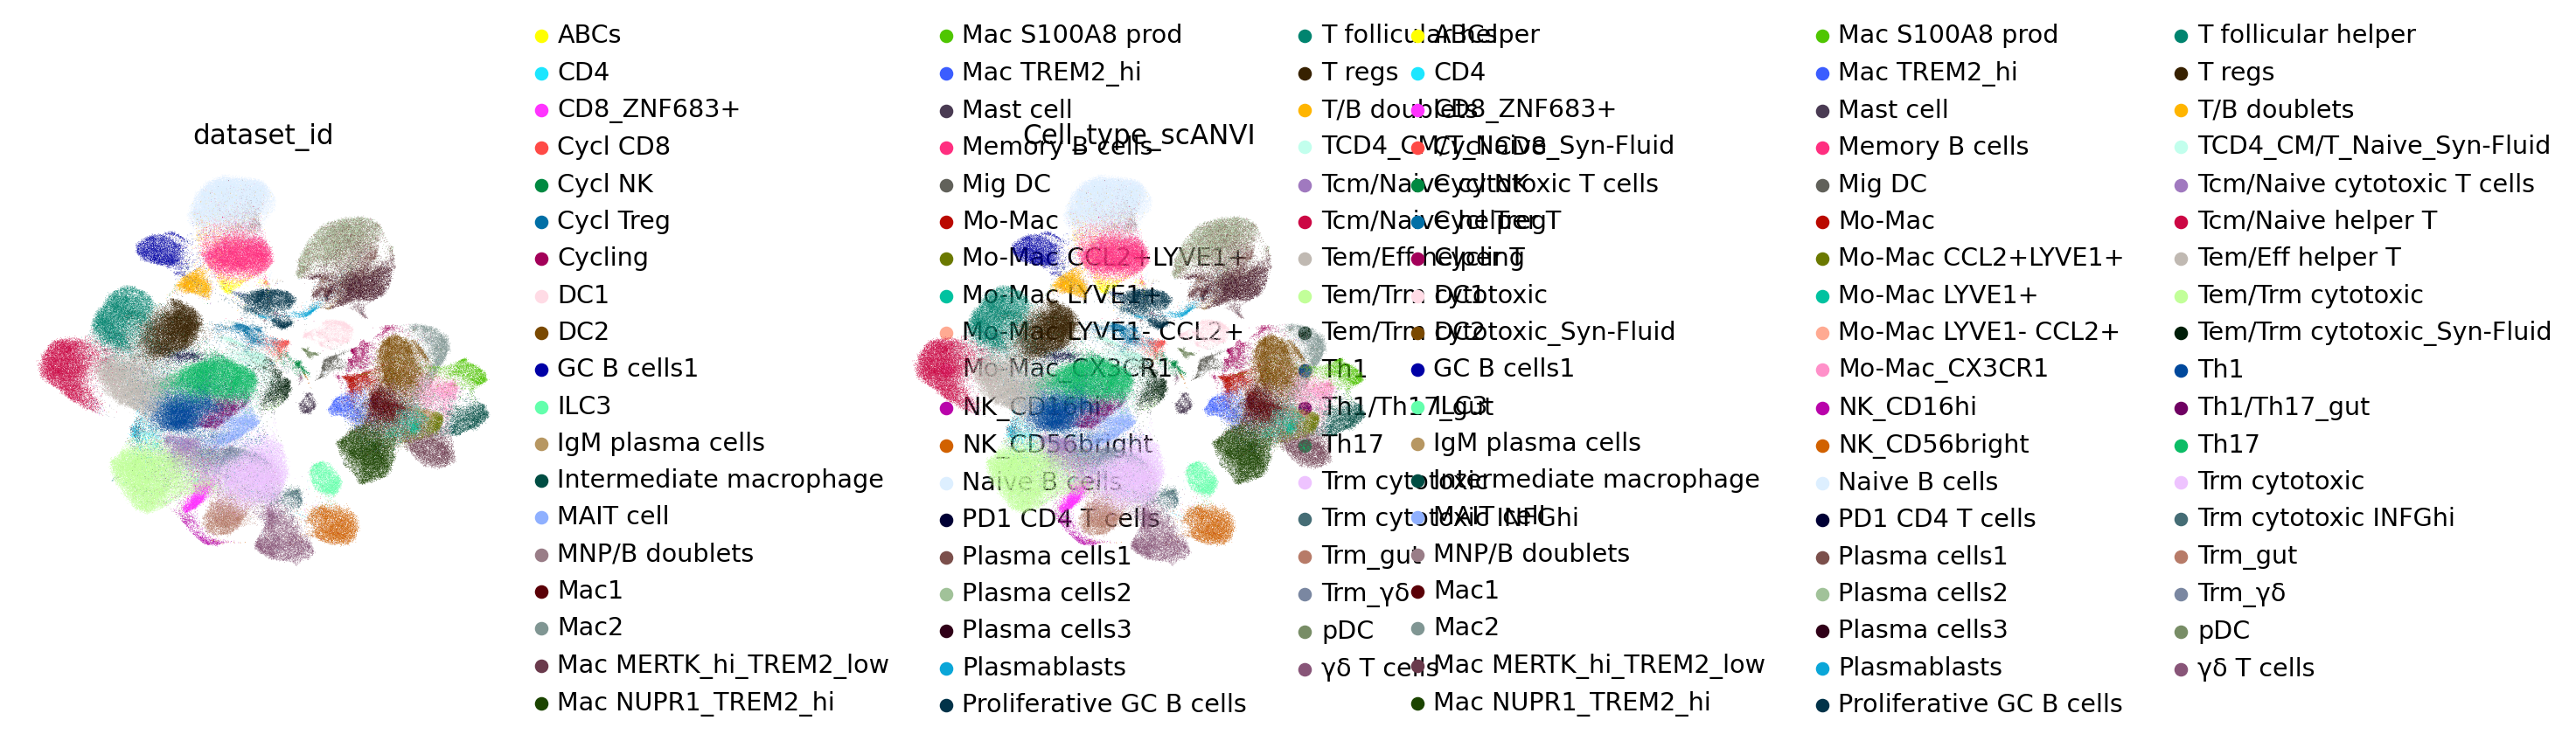

In [52]:
sc.pp.neighbors(reference_latent, n_neighbors=8)
sc.tl.leiden(reference_latent)
sc.tl.umap(reference_latent)
sc.pl.umap(reference_latent,
           color=['dataset_id', 'Cell_type_scANVI'],
           frameon=False,
           wspace=0.6,
           )

In [53]:
reference_latent.obs['predictions'] = scanvae.predict()
print("Acc: {}".format(np.mean(reference_latent.obs.predictions == reference_latent.obs.Cell_type_scANVI)))

Acc: 0.8731828599436477


In [54]:
ref_path = 'ref_model_tissue_for_asthma_and_skin'
scanvae.save(ref_path+"_scanvi", overwrite=True)
vae.save(ref_path+"_scvi", overwrite=True)

In [55]:
pd.DataFrame(adata_ref.var_names, columns=["Genes"]).to_csv("ref_model_tissue_for_asthma_and_skin_scanvi/var_names.csv")

pd.DataFrame(adata_ref.var_names, columns=["Genes"]).to_csv("ref_model_tissue_for_asthma_and_skin_scvi/var_names.csv")

## Surgery with the query dataset

In [56]:
adata_query = adata_query.copy()

In [57]:
model = sca.models.SCANVI.load_query_data(
    adata_query,
    ref_path+"_scanvi",
    freeze_dropout = True,
)
model._unlabeled_indices = np.arange(adata_query.n_obs)
model._labeled_indices = []
print("Labelled Indices: ", len(model._labeled_indices))
print("Unlabelled Indices: ", len(model._unlabeled_indices))

INFO     File ref_model_tissue_for_asthma_and_skin_scanvi/model.pt already downloaded                              
Labelled Indices:  0
Unlabelled Indices:  223443


In [58]:
model.train(
    max_epochs=50,
    plan_kwargs=dict(weight_decay=0.0),
    check_val_every_n_epoch=10,
)

INFO     Training for 50 epochs.                                                                                   


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 50/50: 100%|██████████| 50/50 [31:57<00:00, 38.97s/it, v_num=1, train_loss_step=1.22e+3, train_loss_epoch=1.22e+3]

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [31:57<00:00, 38.35s/it, v_num=1, train_loss_step=1.22e+3, train_loss_epoch=1.22e+3]


In [59]:
#query_latent = sc.AnnData(model.get_latent_representation())
#query_latent.obs['Cell_type_scANVI'] = adata_query.obs['Cell_type_scANVI'].tolist()

In [60]:
#adata_query

In [61]:
#sc.pp.neighbors(query_latent)
#sc.tl.leiden(query_latent)
#sc.tl.umap(query_latent)
#plt.figure()

In [62]:
#query_latent.obs["dataset_id"] = adata_query.obs["dataset_id"]

In [63]:


#sc.pl.umap(
 #   query_latent,
 #   color=["dataset_id", "Cell_type_scANVI"],
 #   frameon=False,
 #   wspace=0.6,
#)

In [64]:
surgery_path = 'surgery_model_tissue_asthma_and_skin'
model.save(surgery_path, overwrite=True)

## Latent representation of reference + query dataset and compute UMAP

In [65]:
adata_full = adata_ref.concatenate(adata_query, batch_key="ref_query")
adata_full

AnnData object with n_obs × n_vars = 588646 × 5000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3', 'cell_source', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'main_predicted_cell_groups', 'leiden', 'ref_query'
    var: 'mt-0-0', 'rb-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts

In [66]:
#full_latent = sc.AnnData(model.get_latent_representation(adata=adata_full))
#full_latent.obs['Cell_type_scANVI'] = adata_full.obs["Cell_type_scANVI"].tolist()
#full_latent.obs['donor_id'] = adata_full.obs['donor_id'].tolist()

In [67]:
#full_latent.obs['dataset_id'] = adata_full.obs['dataset_id'].tolist()

In [68]:

#sc.pp.neighbors(full_latent)
#sc.tl.leiden(full_latent)
#sc.tl.umap(full_latent)
#plt.figure()
#sc.pl.umap(
#    full_latent,
#    color=["dataset_id", "Cell_type_scANVI"],
#    frameon=False,
#    wspace=0.6,
#)

In [69]:
#full_latent.obs['predictions'] = model.predict(adata=adata_full)

In [70]:
#sc.pp.neighbors(full_latent)
#sc.tl.leiden(full_latent)
#sc.tl.umap(full_latent)
#plt.figure()
#sc.pl.umap(
#    full_latent,
#    color=["predictions", "Cell_type_scANVI"],
#    frameon=False,
#    wspace=0.6,
#)

In [71]:
#full_latent

In [72]:
#full_latent[full_latent.obs.Cell_type_scANVI != "Cell_type_scANVI"].obs["predictions"].value_counts()

In [73]:
adata_query.obs.disease.value_counts()

Asthma    18253
Name: disease, dtype: int64

In [74]:
adata_query.obs

,dataset_id,donor_id,tissue,cell_source,disease,disease_status,age,sex,developmental_stage,sample_id,...,Site,tissue_harmo,Enrichment,Location,development_stage,cell_type,ref_query,_scvi_batch,Cell_type_scANVI,_scvi_labels
AAAGTAGTCTACCTGC-0-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AAAGTAGTCTACCTGC,...,NaN,NaN,NaN,NaN,NaN,NaN,0,220,Unknown,56
AAATGCCAGGCAGTCA-0-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AAATGCCAGGCAGTCA,...,NaN,NaN,NaN,NaN,NaN,NaN,0,220,Unknown,56
AACTCTTCACTCGACG-0-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AACTCTTCACTCGACG,...,NaN,NaN,NaN,NaN,NaN,NaN,0,220,Unknown,56
AACTCTTCAGTCGATT-0-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AACTCTTCAGTCGATT,...,NaN,NaN,NaN,NaN,NaN,NaN,0,220,Unknown,56
AAGACCTTCCGTTGCT-0-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AAGACCTTCCGTTGCT,...,NaN,NaN,NaN,NaN,NaN,NaN,0,220,Unknown,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTGTTCCACAA-1-4820STDY7389014-1,Skin_Reynolds_et_al,S3,Epidermis,NaN,NaN,Healthy,NaN,Female,NaN,NaN,...,non_lesion,Epidermis,Lymphocytes,Breast,adult,Treg,1,236,Unknown,56
TTTGGTTTCGCCTGTT-1-4820STDY7389014-1,Skin_Reynolds_et_al,S3,Epidermis,NaN,NaN,Healthy,NaN,Female,NaN,NaN,...,non_lesion,Epidermis,Lymphocytes,Breast,adult,Th,1,236,Unknown,56
TTTGTCAAGGAATCGC-1-4820STDY7389014-1,Skin_Reynolds_et_al,S3,Epidermis,NaN,NaN,Healthy,NaN,Female,NaN,NaN,...,non_lesion,Epidermis,Lymphocytes,Breast,adult,Th,1,236,Unknown,56
TTTGTCAAGGACTGGT-1-4820STDY7389014-1,Skin_Reynolds_et_al,S3,Epidermis,NaN,NaN,Healthy,NaN,Female,NaN,NaN,...,non_lesion,Epidermis,Lymphocytes,Breast,adult,Th,1,236,Unknown,56


In [75]:
adata_query.obs["tissue_harmo"].value_counts()

Dermis       108664
Epidermis     96526
Name: tissue_harmo, dtype: int64

In [76]:
adata_query.obs["tissue_harmo"] = adata_query.obs["tissue"]

In [77]:
adata_query

AnnData object with n_obs × n_vars = 223443 × 5000
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'main_predicted_cell_groups', 'leiden', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 'development_stage', 'cell_type', 'ref_query', '_scvi_batch', 'Cell_type_scANVI', '_scvi_labels'
    var: 'gene_ids-SKN8090524-1', 'feature_types-SKN8090524-1', 'mt-1', 'rb-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    layers: 'counts'

In [78]:
adata_query.obs.disease_status.value_counts()


Healthy      89811
Eczema       76560
Psoriasis    38819
Name: disease_status, dtype: int64

In [ ]:
#adata_query.obs.dataset_id == "Skin_Reynolds_et_al"

In [79]:
ind = np.where(np.array(adata_query.obs.dataset_id == "Skin_Reynolds_et_al"))

In [80]:
adata_query.obs.tissue = adata_query.obs["tissue"].astype("str")
adata_query.obs.disease = adata_query.obs.disease.astype("str")

In [81]:
adata_query.obs.disease.iloc[ind] = adata_query.obs.disease_status.iloc[ind]

/var/tmp/ipykernel_793977/2360241852.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_query.obs.disease.iloc[ind] = adata_query.obs.disease_status.iloc[ind]


In [82]:
adata_query.obs["disease"].value_counts()

Healthy      89811
Eczema       76560
Psoriasis    38819
Asthma       18253
Name: disease, dtype: int64

In [83]:
adata_query.obs["disease_tissue"] = adata_query.obs.disease + "_" + adata_query.obs.tissue

In [84]:
adata_query.obs["disease_tissue"].value_counts(dropna=False)

Eczema_Epidermis       48165
Healthy_Dermis         47549
Healthy_Epidermis      42262
Psoriasis_Dermis       32720
Eczema_Dermis          28395
Asthma_lung            18253
Psoriasis_Epidermis     6099
Name: disease_tissue, dtype: int64

In [85]:
#adata_query.obs["disease"] = adata_query.obs["disease_tissue"] 

In [86]:
#adata_query.obs["disease_tissue"] = adata_query.obs["disease_status"].astype("str") + "_" + adata_query.obs["tissue_harmo"].astype("str")

adata_query.obs["disease_tissue"] = adata_query.obs["disease_tissue"].astype("category")

In [87]:
adata_ref.obs.disease_tissue.value_counts()

Paed_IBD_colon                  23299
hashimoto_thyroid               20035
Paed_IBD_ileum                  10720
CD_ileum                         9474
Uninfl_CD_ileum                  7345
Paed_Healthy_ileum               7334
CD_spondyloarthritis_colon        932
Healthy_colon                     818
CD_colon                          778
Resitant_treat_RA_syno_membr      691
spondyloarhtriti_colon            553
Remission_RA_syno_membr           232
Naïve_treat_RA_syno_membr         123
Name: disease_tissue, dtype: int64

In [88]:
#adata_query.obs.Site.value_counts()

In [89]:
adata_ref

AnnData object with n_obs × n_vars = 365203 × 5000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0', 'total_counts-0-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0', 'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'n_cells_by_counts-1-0-0', 'mean_counts-1-0-0', 'pct_dropout_by_counts-1-0-0', 'total_counts-1-0-0', 'gene_symbol-1-0-0-0-0-0-0-1-1-0', 'n_cells_by_c

In [90]:
adata_full = adata_ref.concatenate(adata_query, batch_key="ref_query")
adata_full

AnnData object with n_obs × n_vars = 588646 × 5000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3', 'cell_source', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'main_predicted_cell_groups', 'leiden', 'ref_query'
    var: 'mt-0-0', 'rb-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts

In [91]:
adata_full.obs.disease.value_counts(dropna=False)

Healthy                       115515
Uninflam_CD                    88829
Eczema                         76560
Paediatric IBD                 57503
Crohn's Disease                45659
Psoriatic arthritis            41043
Psoriasis                      38819
Hashimoto’s thyroiditis        33413
Rheumatoid Arthritis           29631
Oligoarticular JIA             18862
Asthma                         18253
Paed_Healthy                   13266
Undifferentiated Arthritis      6910
Spondyloarhtritis               2445
CD + Spondyloarthritis          1938
Name: disease, dtype: int64

In [92]:
adata_full.obs["disease_label_trans"] = adata_full.obs.disease.astype("str") + "_" + adata_full.obs.tissue_harmo.astype("str")

In [93]:
adata_full.obs['disease_label_trans'].value_counts(dropna = False)

Uninflam_CD_Ileum                               74829
Eczema_Epidermis                                48165
Healthy_Dermis                                  47549
Healthy_Epidermis                               42262
Psoriatic arthritis_Synovial fluid              40392
Paediatric IBD_Colon                            37406
Crohn's Disease_Ileum                           35742
Hashimoto’s thyroiditis_Thyroid                 33413
Psoriasis_Dermis                                32720
Rheumatoid Arthritis_Synovial membrane          29631
Eczema_Dermis                                   28395
Paediatric IBD_Ileum                            20097
Oligoarticular JIA_Synovial fluid               18862
Asthma_lung                                     18253
Uninflam_CD_Colon                               14000
Healthy_Colon                                   13835
Paed_Healthy_Ileum                              13266
Crohn's Disease_Colon                            9917
Undifferentiated Arthritis_S

In [94]:
adata_full.obs['disease'].value_counts(dropna = False)

Healthy                       115515
Uninflam_CD                    88829
Eczema                         76560
Paediatric IBD                 57503
Crohn's Disease                45659
Psoriatic arthritis            41043
Psoriasis                      38819
Hashimoto’s thyroiditis        33413
Rheumatoid Arthritis           29631
Oligoarticular JIA             18862
Asthma                         18253
Paed_Healthy                   13266
Undifferentiated Arthritis      6910
Spondyloarhtritis               2445
CD + Spondyloarthritis          1938
Name: disease, dtype: int64

In [95]:
adata_full.obs['scanvi_predictions'] = model.predict(adata=adata_full)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [96]:
adata_full.obs[['disease_label_trans', 'scanvi_predictions']].value_counts()

disease_label_trans                 scanvi_predictions
Eczema_Epidermis                    Mo-Mac CCL2+LYVE1+    15324
Eczema_Dermis                       Mo-Mac CCL2+LYVE1+    12479
Healthy_Epidermis                   Mig DC                11527
Uninflam_CD_Ileum                   Trm cytotoxic         10963
Psoriatic arthritis_Synovial fluid  Tem/Trm cytotoxic     10505
                                                          ...  
Psoriasis_Epidermis                 Mac S100A8 prod           1
Asthma_lung                         Mo-Mac CCL2+LYVE1+        1
Healthy_Ileum                       Mac NUPR1_TREM2_hi        1
Spondyloarhtritis_Colon             Plasma cells3             1
Psoriasis_Dermis                    Plasmablasts              1
Length: 1144, dtype: int64

In [97]:
adata_full.obs.dataset_id.value_counts(dropna=False)

Skin_Reynolds_et_al            205190
Kong_et_al_2023                101054
GSE134809_Martin_et_al_2019     47390
E-MTAB-8322_Stefeno_2020        41573
E-MTAB-9492_Penkava_2020        38906
GSE121380_Huang_2019            37406
Elmentaite_2020                 34902
Qian_Yue_Zhang_2022             33413
Martin_JIA_2019                 18862
Braga_asthma                    18253
GSE163314_Lefferts_2021          9560
GSE161500_Abji_2020              2137
Name: dataset_id, dtype: int64

In [98]:
adata_full.obs.Cell_type_scANVI.value_counts()

Unknown                        223443
Tem/Trm cytotoxic               25831
Trm cytotoxic                   24807
Naive B cells                   21693
Th17                            19936
Tem/Eff helper T                19195
T regs                          15089
Memory B cells                  14690
Th1                             14476
Tcm/Naive helper T              13136
T follicular helper             13106
Mac NUPR1_TREM2_hi              13065
DC2                             10791
Plasma cells1                    9885
Plasma cells2                    9014
γδ T cells                       8625
Mac1                             7422
Plasma cells3                    6881
Mac MERTK_hi_TREM2_low           6789
NK_CD56bright                    6394
Proliferative GC B cells         6391
Trm_gut                          5944
MAIT cell                        5659
GC B cells1                      5140
Mac2                             4848
Trm_γδ                           4631
Tcm/Naive cy

In [99]:
adata_full

AnnData object with n_obs × n_vars = 588646 × 5000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3', 'cell_source', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'main_predicted_cell_groups', 'leiden', 'ref_query', 'disease_label_trans', 'scanvi_predictions'
    var: 'mt-0-0', 'rb-0-0', 'n_cells_by_counts-0-0-0-0-0', 'm

In [100]:
adata_full.obs["Cell_type_scANVI_asthma_skin"] = adata_full.obs["scanvi_predictions"]

In [101]:
adata_full.obs.dataset_id.unique()

array(['Qian_Yue_Zhang_2022', 'GSE121380_Huang_2019',
       'E-MTAB-8322_Stefeno_2020', 'GSE134809_Martin_et_al_2019',
       'Elmentaite_2020', 'GSE163314_Lefferts_2021', 'Martin_JIA_2019',
       'Kong_et_al_2023', 'GSE161500_Abji_2020',
       'E-MTAB-9492_Penkava_2020', 'Braga_asthma', 'Skin_Reynolds_et_al'],
      dtype=object)

In [102]:
ind = np.where(adata_full.obs.dataset_id.isin(['Qian_Yue_Zhang_2022', 'GSE121380_Huang_2019', 'E-MTAB-8322_Stefeno_2020', 'GSE134809_Martin_et_al_2019',
       'Elmentaite_2020', 'GSE163314_Lefferts_2021', 'Martin_JIA_2019', 'Kong_et_al_2023', 'GSE161500_Abji_2020', 'E-MTAB-9492_Penkava_2020']))

In [103]:
ind[0].shape[0] + adata_query.n_obs

588646

In [104]:
adata_query.obs.tissue = adata_query.obs["tissue"].astype("str")
adata_query.obs.disease = adata_query.obs.disease.astype("str")

In [105]:
adata_full.obs["Cell_type_scANVI_asthma_skin"].iloc[ind] = adata_full.obs["Cell_type_scANVI"].iloc[ind]

/var/tmp/ipykernel_793977/613559261.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_full.obs["Cell_type_scANVI_asthma_skin"].iloc[ind] = adata_full.obs["Cell_type_scANVI"].iloc[ind]


In [106]:
adata_full.obs["Cell_type_scANVI_asthma_skin"] = adata_full.obs["Cell_type_scANVI_asthma_skin"].astype("category")

In [107]:
pd.DataFrame(adata_full.obs).to_csv("Obs_Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K_with_UMAP_from_gpu_with_asthma_Skin_data.csv")

In [108]:
!pwd 

/home/jupyter/data


In [109]:
#!rclone copy ../data/ 'gdrive:Projects/gcp_gpu/data_gpu/'

In [110]:
!rclone copy Obs_Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K_with_UMAP_from_gpu_with_asthma_Skin_data.csv\
'gdrive:gcp_gpu/data_gpu/'

In [111]:
!rclone copy surgery_model_tissue_asthma_and_skin/\
'gdrive:gcp_gpu/data_gpu/surgery_model_tissue_asthma_and_skin/'

In [112]:
!rclone copy ref_model_tissue_for_asthma_and_skin_scanvi/\
'gdrive:gcp_gpu/data_gpu/ref_model_tissue_for_asthma_and_skin_scanvi/'

In [113]:
!rclone copy ref_model_tissue_for_asthma_and_skin_scvi/\
'gdrive:gcp_gpu/data_gpu/ref_model_tissue_for_asthma_and_skin_scvi/'

In [114]:
!rclone copy SCANVI_Tissue_asthma_skin.ipynb\
'gdrive:gcp_gpu/data_gpu/SCANVI_Tissue_asthma_skin.ipynb'

In [ ]:
sc.pp.neighbors(adata_full)
sc.tl.leiden(adata_full)
sc.tl.umap(adata_full)
plt.figure()
sc.pl.umap(
    adata_full,
    color=["Cell_type_scANVI_asthma_skin"],
    frameon=False,
    wspace=0.6,
)

         Falling back to preprocessing with `sc.pp.pca` and default params.
